#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("Toronto Island Ferry Tickets.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()


,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0


In [6]:
df.tail()

,_id,Timestamp,Redemption Count,Sales Count
261533,261534,2015-05-04T16:00:00,0,2
261534,261535,2015-05-01T16:00:00,1,0
261535,261536,2015-05-01T15:45:00,0,1
261536,261537,2015-05-01T15:15:00,0,2
261537,261538,2015-05-01T13:30:00,0,1


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 261538
Number of columns: 4


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261538 entries, 0 to 261537
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   _id               261538 non-null  int64 
 1   Timestamp         261538 non-null  object
 2   Redemption Count  261538 non-null  int64 
 3   Sales Count       261538 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 8.0+ MB


In [9]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
_id                 0
Timestamp           0
Redemption Count    0
Sales Count         0
dtype: int64


In [10]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [11]:
df = df.drop_duplicates()

print("Duplicates removed.")
print("New dataset shape:", df.shape)

Duplicates removed.
New dataset shape: (261538, 4)


#### TIMESTAMP CLEANING

In [12]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

print("Timestamp converted successfully.")

Timestamp converted successfully.


In [13]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

print("Timestamp converted successfully.")

Timestamp converted successfully.


In [14]:
df = df.dropna(subset=["Timestamp"])

print("Rows with missing timestamps removed.")

Rows with missing timestamps removed.


In [16]:
df = df.sort_values("Timestamp")

df = df.reset_index(drop=True)

df.head()

,_id,Timestamp,Redemption Count,Sales Count
0,261538,2015-05-01 13:30:00,0,1
1,261537,2015-05-01 15:15:00,0,2
2,261536,2015-05-01 15:45:00,0,1
3,261535,2015-05-01 16:00:00,1,0
4,261534,2015-05-04 16:00:00,0,2


In [18]:
print(df["Redemption Count"].describe())

count    261538.000000
mean         48.885030
std         104.549336
min           0.000000
25%           3.000000
50%          11.000000
75%          40.000000
max        7216.000000
Name: Redemption Count, dtype: float64


In [19]:
print(df["Sales Count"].describe())

count    261538.000000
mean         49.599106
std          99.862285
min           0.000000
25%           3.000000
50%          13.000000
75%          48.000000
max        7229.000000
Name: Sales Count, dtype: float64


In [23]:
df.describe()

,_id,Timestamp,Redemption Count,Sales Count
count,261538.000000,261538,261538.000000,261538.000000
mean,130769.500000,2020-10-29 15:30:22.722128384,48.885030,49.599106
min,1.000000,2015-05-01 13:30:00,0.000000,0.000000
25%,65385.250000,2018-03-31 11:18:45,3.000000,3.000000
50%,130769.500000,2020-11-30 18:22:30,11.000000,13.000000
75%,196153.750000,2023-07-01 19:11:15,40.000000,48.000000
max,261538.000000,2025-12-21 22:30:00,7216.000000,7229.000000
std,75499.661689,NaN,104.549336,99.862285


In [24]:
df["Hour"] = df["Timestamp"].dt.hour

df.head()

,_id,Timestamp,Redemption Count,Sales Count,Hour
0,261538,2015-05-01 13:30:00,0,1,13
1,261537,2015-05-01 15:15:00,0,2,15
2,261536,2015-05-01 15:45:00,0,1,15
3,261535,2015-05-01 16:00:00,1,0,16
4,261534,2015-05-04 16:00:00,0,2,16


In [27]:
df["Day"] = df["Timestamp"].dt.day

In [28]:
df["DayOfWeek"] = df["Timestamp"].dt.day_name()

In [29]:
df["Month"] = df["Timestamp"].dt.month

In [30]:
df["MonthName"] = df["Timestamp"].dt.month_name()

In [31]:
df["Year"] = df["Timestamp"].dt.year

In [32]:
df["DayType"] = df["Timestamp"].dt.dayofweek.apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

In [35]:
df["Net Movement"] = (
    df["Sales Count"] - df["Redemption Count"]
)

df.head()

,_id,Timestamp,Redemption Count,Sales Count,Hour,Day,DayOfWeek,Month,MonthName,Year,DayType,Net Movement
0,261538,2015-05-01 13:30:00,0,1,13,1,Friday,5,May,2015,Weekday,1
1,261537,2015-05-01 15:15:00,0,2,15,1,Friday,5,May,2015,Weekday,2
2,261536,2015-05-01 15:45:00,0,1,15,1,Friday,5,May,2015,Weekday,1
3,261535,2015-05-01 16:00:00,1,0,16,1,Friday,5,May,2015,Weekday,-1
4,261534,2015-05-04 16:00:00,0,2,16,4,Monday,5,May,2015,Weekday,2


In [37]:
df.head()

,_id,Timestamp,Redemption Count,Sales Count,Hour,Day,DayOfWeek,Month,MonthName,Year,DayType,Net Movement
0,261538,2015-05-01 13:30:00,0,1,13,1,Friday,5,May,2015,Weekday,1
1,261537,2015-05-01 15:15:00,0,2,15,1,Friday,5,May,2015,Weekday,2
2,261536,2015-05-01 15:45:00,0,1,15,1,Friday,5,May,2015,Weekday,1
3,261535,2015-05-01 16:00:00,1,0,16,1,Friday,5,May,2015,Weekday,-1
4,261534,2015-05-04 16:00:00,0,2,16,4,Monday,5,May,2015,Weekday,2


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261538 entries, 0 to 261537
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   _id               261538 non-null  int64         
 1   Timestamp         261538 non-null  datetime64[ns]
 2   Redemption Count  261538 non-null  int64         
 3   Sales Count       261538 non-null  int64         
 4   Hour              261538 non-null  int32         
 5   Day               261538 non-null  int32         
 6   DayOfWeek         261538 non-null  object        
 7   Month             261538 non-null  int32         
 8   MonthName         261538 non-null  object        
 9   Year              261538 non-null  int32         
 10  DayType           261538 non-null  object        
 11  Net Movement      261538 non-null  int64         
dtypes: datetime64[ns](1), int32(4), int64(4), object(3)
memory usage: 20.0+ MB


#### KPI ANALYSIS

In [45]:
total_sales = df["Sales Count"].sum()

print("Total Tickets Sold:", total_sales )

Total Tickets Sold: 12972051


In [46]:
total_redemptions = df["Redemption Count"].sum()

print("Total Tickets Redeemed:", total_redemptions)

Total Tickets Redeemed: 12785293


In [47]:
total_net_movement = df["Net Movement"].sum()

print("Total Net Passenger Movement:", total_net_movement)

Total Net Passenger Movement: 186758


#### HOURLY ANALYSIS

In [50]:
hourly_sales = df.groupby("Hour")["Sales Count"].sum()

hourly_sales

Hour
0       55357
1       24314
2       11131
3        6734
4        3440
5        5611
6       71790
7      140104
8      352362
9      756876
10    1087669
11    1382050
12    1423362
13    1398298
14    1346528
15    1208209
16    1020424
17     800584
18     583343
19     419508
20     299957
21     238737
22     201737
23     133926
Name: Sales Count, dtype: int64

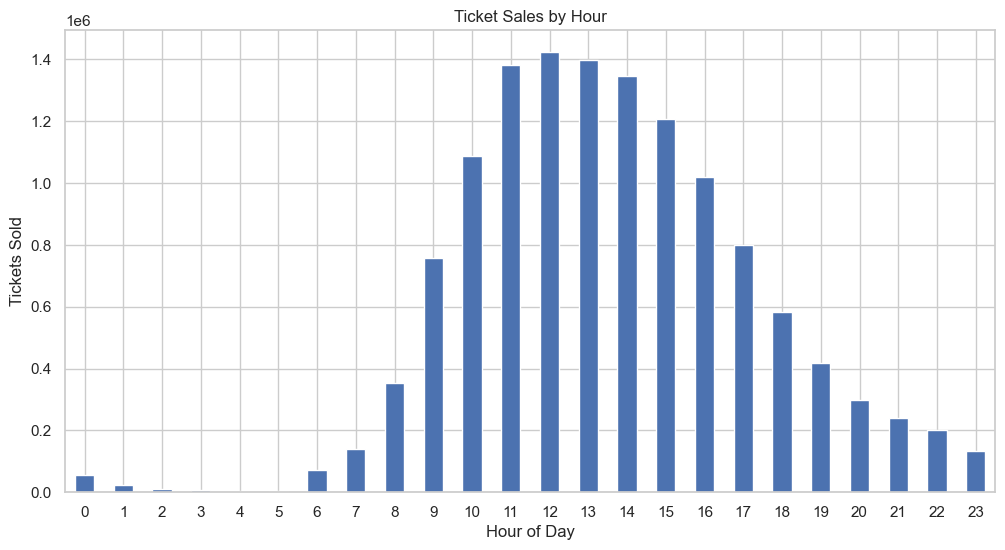

In [51]:
plt.figure(figsize=(12, 6))

hourly_sales.plot(kind="bar")

plt.title("Ticket Sales by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Tickets Sold")

plt.xticks(rotation=0)

plt.show()

In [53]:
hourly_redemptions = df.groupby("Hour")["Redemption Count"].sum()

hourly_redemptions

Hour
0         356
1        2232
2        3475
3        3357
4        2289
5        2151
6       84667
7      108757
8      256088
9      674964
10    1176322
11    1467484
12    1509483
13    1466331
14    1417530
15    1254838
16    1053120
17     810046
18     586237
19     390974
20     235887
21     139066
22      90271
23      49368
Name: Redemption Count, dtype: int64

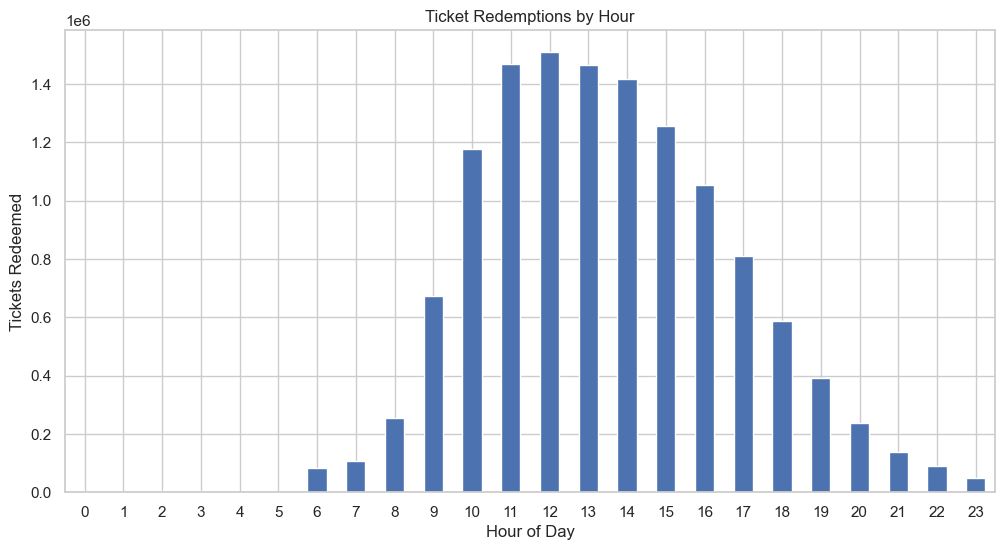

In [54]:
plt.figure(figsize=(12, 6))

hourly_redemptions.plot(kind="bar")

plt.title("Ticket Redemptions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Tickets Redeemed")

plt.xticks(rotation=0)

plt.show()

In [56]:
hourly_comparison = df.groupby("Hour")[
    ["Sales Count", "Redemption Count"]
].sum()

hourly_comparison

,Sales Count,Redemption Count
Hour,,
0,55357,356
1,24314,2232
2,11131,3475
3,6734,3357
4,3440,2289
5,5611,2151
6,71790,84667
7,140104,108757
8,352362,256088


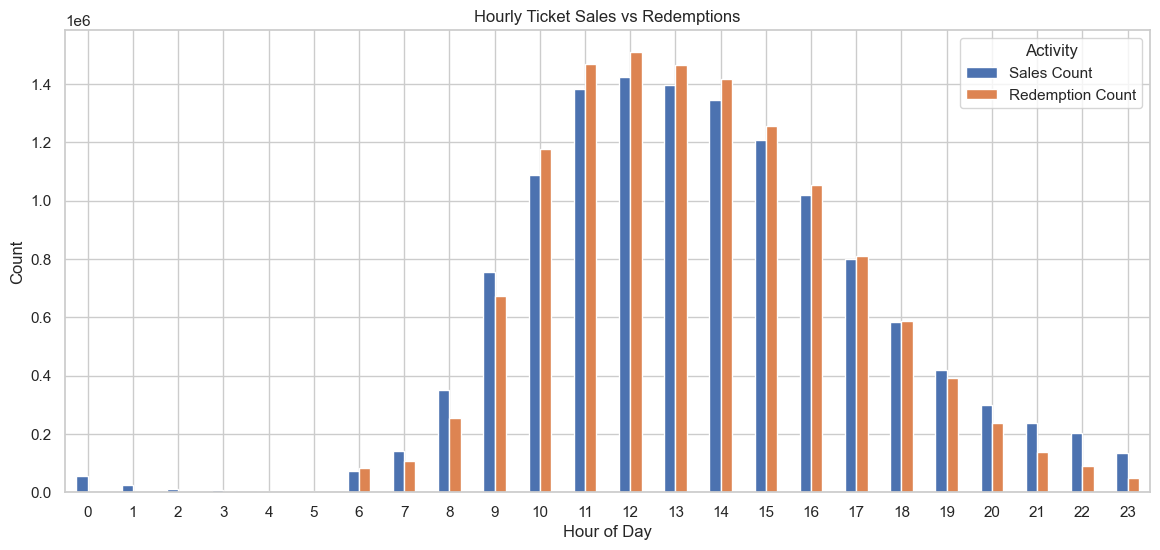

In [57]:
hourly_comparison.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Hourly Ticket Sales vs Redemptions")
plt.xlabel("Hour of Day")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.legend(
    title="Activity"
)

plt.show()

#### DAILY ANALYSIS

In [65]:
daily_sales = df.resample(
    "D",
    on="Timestamp"
)["Sales Count"].sum()

daily_sales.head()

Timestamp
2015-05-01      4
2015-05-02      0
2015-05-03      0
2015-05-04     75
2015-05-05    549
Freq: D, Name: Sales Count, dtype: int64

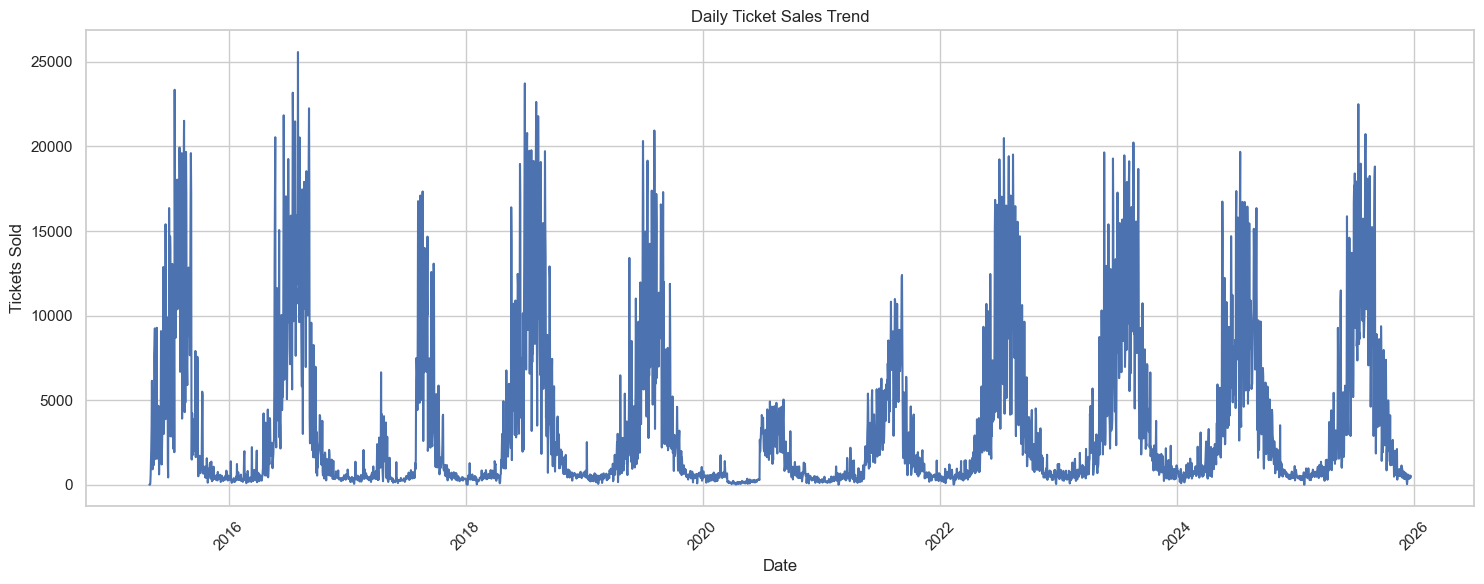

In [66]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales.index,
    daily_sales.values
)

plt.title("Daily Ticket Sales Trend")
plt.xlabel("Date")
plt.ylabel("Tickets Sold")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [70]:
monthly_sales = df.groupby("Month")["Sales Count"].sum()

monthly_sales

Month
1      130455
2      146179
3      201753
4      401395
5     1090751
6     1814395
7     3083858
8     3442762
9     1605867
10     638215
11     254575
12     161846
Name: Sales Count, dtype: int64

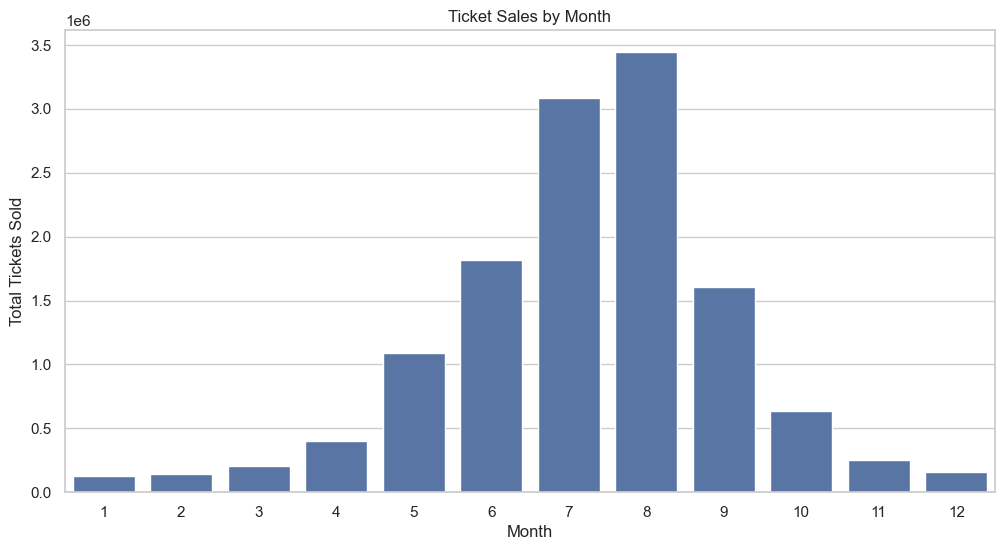

In [71]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)

plt.title("Ticket Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Tickets Sold")

plt.show()

In [72]:
yearly_sales = df.groupby("Year")["Sales Count"].sum()

yearly_sales

Year
2015    1189620
2016    1518428
2017     682346
2018    1463589
2019    1249725
2020     366606
2021     782368
2022    1346659
2023    1491473
2024    1373563
2025    1507674
Name: Sales Count, dtype: int64

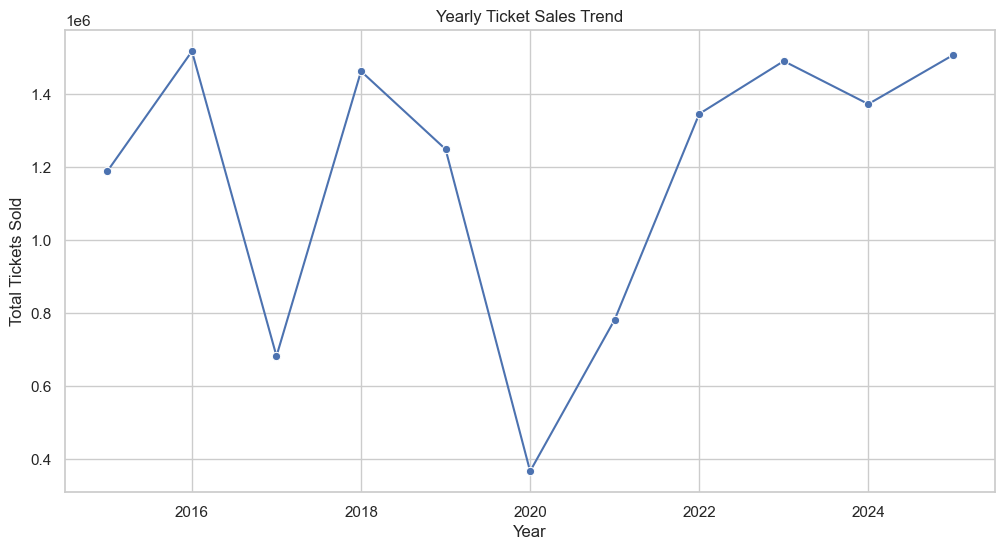

In [73]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=yearly_sales.index,
    y=yearly_sales.values,
    marker="o"
)

plt.title("Yearly Ticket Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Tickets Sold")

plt.show()

In [75]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales = (
    df.groupby("DayOfWeek")["Sales Count"]
    .sum()
    .reindex(day_order)
)

day_sales

DayOfWeek
Monday       1670609
Tuesday      1331860
Wednesday    1444624
Thursday     1461639
Friday       1784931
Saturday     2727394
Sunday       2550994
Name: Sales Count, dtype: int64

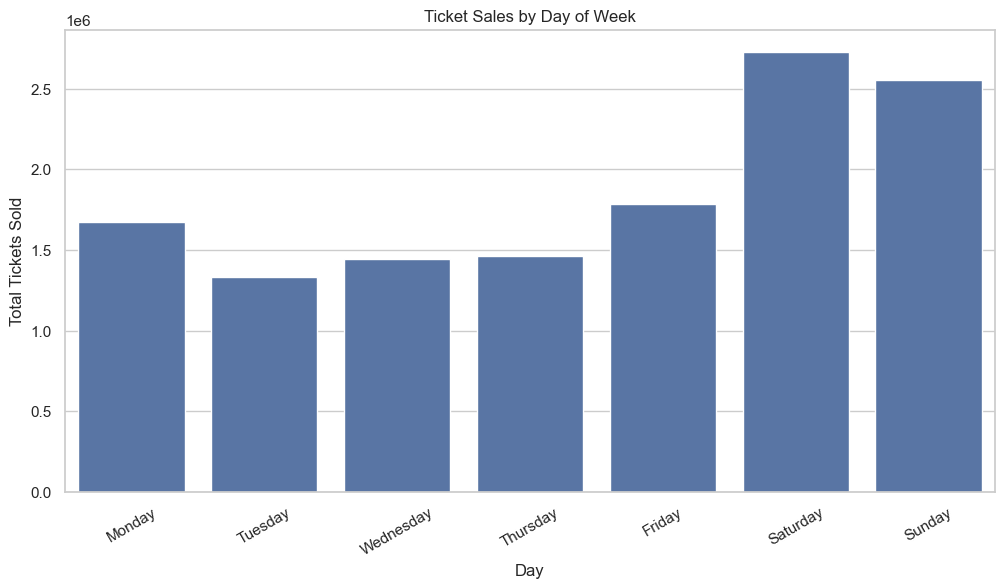

In [76]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=day_sales.index,
    y=day_sales.values
)

plt.title("Ticket Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Tickets Sold")

plt.xticks(rotation=30)

plt.show()

In [80]:
peak_sales_hour = hourly_sales.idxmax()
peak_sales_value = hourly_sales.max()

print("Peak Ticket Sales Hour:", peak_sales_hour)
print("Tickets Sold:", peak_sales_value)


Peak Ticket Sales Hour: 12
Tickets Sold: 1423362


In [81]:
peak_redemption_hour = hourly_redemptions.idxmax()
peak_redemption_value = hourly_redemptions.max()

print("Peak Redemption Hour:", peak_redemption_hour)
print("Tickets Redeemed:", peak_redemption_value)

Peak Redemption Hour: 12
Tickets Redeemed: 1509483


In [82]:
top_hours = hourly_sales.sort_values(
    ascending=False
).head(5)

print("Top 5 busiest hours:")
print(top_hours)

Top 5 busiest hours:
Hour
12    1423362
13    1398298
11    1382050
14    1346528
15    1208209
Name: Sales Count, dtype: int64


In [83]:
off_peak_hours = hourly_sales.sort_values(
    ascending=True
).head(5)

print("Top 5 off-peak hours:")
print(off_peak_hours)


Top 5 off-peak hours:
Hour
4     3440
5     5611
3     6734
2    11131
1    24314
Name: Sales Count, dtype: int64


In [87]:
print("==========================================")
print(" TORONTO FERRY ANALYTICS - KPI SUMMARY")
print("==========================================")

print("Total Tickets Sold:", total_sales)

print("Total Tickets Redeemed:", total_redemptions)

print("Total Net Passenger Movement:", total_net_movement)

print("Peak Sales Hour:", peak_sales_hour)

print("Peak Sales Count:", peak_sales_value)

print("Peak Redemption Hour:", peak_redemption_hour)

print("Peak Redemption Count:", peak_redemption_value)

print("==========================================")

 TORONTO FERRY ANALYTICS - KPI SUMMARY
Total Tickets Sold: 12972051
Total Tickets Redeemed: 12785293
Total Net Passenger Movement: 186758
Peak Sales Hour: 12
Peak Sales Count: 1423362
Peak Redemption Hour: 12
Peak Redemption Count: 1509483


In [88]:
df.head(10)

,_id,Timestamp,Redemption Count,Sales Count,Hour,Day,DayOfWeek,Month,MonthName,Year,DayType,Net Movement
0,261538,2015-05-01 13:30:00,0,1,13,1,Friday,5,May,2015,Weekday,1
1,261537,2015-05-01 15:15:00,0,2,15,1,Friday,5,May,2015,Weekday,2
2,261536,2015-05-01 15:45:00,0,1,15,1,Friday,5,May,2015,Weekday,1
3,261535,2015-05-01 16:00:00,1,0,16,1,Friday,5,May,2015,Weekday,-1
4,261534,2015-05-04 16:00:00,0,2,16,4,Monday,5,May,2015,Weekday,2
5,261533,2015-05-04 16:15:00,0,2,16,4,Monday,5,May,2015,Weekday,2
6,261532,2015-05-04 16:30:00,0,3,16,4,Monday,5,May,2015,Weekday,3
7,261531,2015-05-04 16:45:00,0,3,16,4,Monday,5,May,2015,Weekday,3
8,261530,2015-05-04 17:00:00,4,6,17,4,Monday,5,May,2015,Weekday,2
9,261529,2015-05-04 17:15:00,8,11,17,4,Monday,5,May,2015,Weekday,3


In [89]:
df.to_csv(
    "cleaned_toronto_ferry_data.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
